# Exploratory Data Analysis (EDA) & Statistical Inference

In this notebook, I will connect to my cloud database (Neon) to retrieve the clinical and lifestyle datasets. My main objective is to perform an exploratory data analysis and hypothesis testing to determine if there is a statistically significant relationship between vigorous physical activity and survival months in oncology patients.

In [1]:
#libraries
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
from dotenv import load_dotenv


In [2]:
sns.set_theme(style="whitegrid")

## 1. Data Retrieval
I use environment variables to securely connect to my PostgreSQL database hosted on Neon. I will load the `nhanes_analytics_data` table into a Pandas DataFrame to analyze the impact of lifestyle habits.

In [3]:
#Connect to Neon database
load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# Fetch the analytics dataset
query = "SELECT * FROM nhanes_analytics_data"
df_eda = pd.read_sql(query, engine)

In [5]:
df_eda.shape

(547, 278)

## 2. Hypothesis Testing: Exercise vs. Survival
I want to statistically validate if engaging in vigorous recreational activities (`vigorous_recreation`) has a significant impact on overall survival (`survival_months`).

* **Null Hypothesis (H0):** There is no significant difference in survival months between active and sedentary patients.
* **Alternative Hypothesis (H1):** There is a statistically significant difference in survival months between the two groups.

I will use Welch's T-test (independent sample t-test), which is robust for unequal variances and unequal sample sizes.

In [13]:
# Force my target columns to be strictly numeric, converting any hidden text to NaN
df_eda['vigorous_recreation'] = pd.to_numeric(df_eda['vigorous_recreation'], errors='coerce')
df_eda['survival_months'] = pd.to_numeric(df_eda['survival_months'], errors='coerce')

In [14]:
# Drop rows with missing values in my target columns to ensure accurate statistics
df_clean = df_eda.dropna(subset=['vigorous_recreation', 'survival_months'])

In [15]:
# Separate my cohorts: 1.0 = Vigorous exercise, 2.0 = Sedentary (No vigorous exercise)
active_patients = df_clean[df_clean['vigorous_recreation'] == 1.0]['survival_months']
inactive_patients = df_clean[df_clean['vigorous_recreation'] == 2.0]['survival_months']

In [16]:
# Perform Welch's T-test
t_stat, p_value = stats.ttest_ind(active_patients, inactive_patients, equal_var=False)

print("HYPOTHESIS TEST RESULTS")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Evaluate significance (Alpha = 0.05)
if p_value < 0.05:
    print("\nResult: STATISTICALLY SIGNIFICANT.")
    print("I reject the Null Hypothesis. I found a significant difference in survival months based on exercise habits.")
else:
    print("\nResult: NOT SIGNIFICANT.")
    print("I fail to reject the Null Hypothesis. No significant difference was found in this specific sample.")


HYPOTHESIS TEST RESULTS
T-Statistic: 3.1992
P-Value: 0.0018

Result: STATISTICALLY SIGNIFICANT.
I reject the Null Hypothesis. I found a significant difference in survival months based on exercise habits.


## 3. Data Visualization
To better understand the distribution of survival months across both cohorts, I will plot a boxplot. This visualization helps me identify the median survival time, interquartile ranges, and potential outliers in both the active and sedentary groups.

C:\Users\lugon\AppData\Local\Temp\ipykernel_18672\1733833661.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


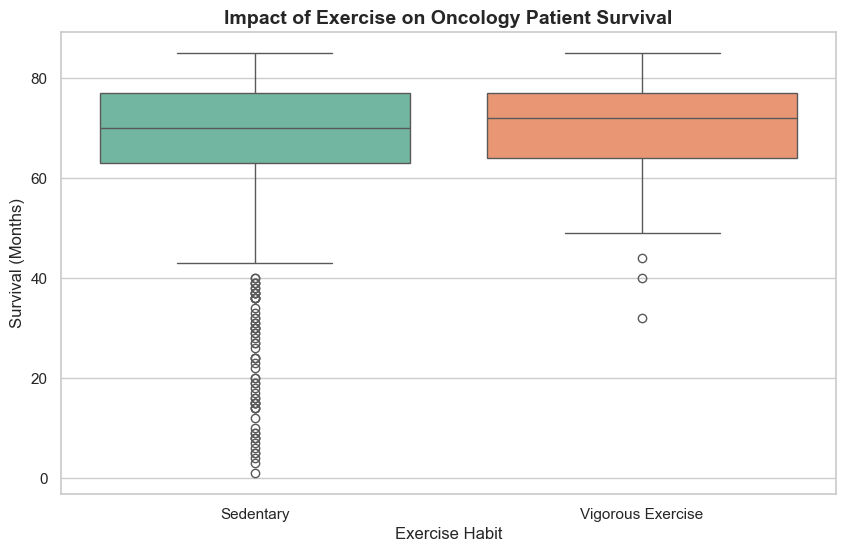

In [17]:
plt.figure(figsize=(10, 6))

# Map numerical values to descriptive labels just for my plot
plot_data = df_clean.copy()
plot_data['vigorous_recreation'] = plot_data['vigorous_recreation'].replace({
    1.0: 'Vigorous Exercise', 
    2.0: 'Sedentary'
})

# Create boxplot
ax = sns.boxplot(
    x='vigorous_recreation', 
    y='survival_months',
    data=plot_data,
    palette="Set2"
)

# Format the chart
plt.title("Impact of Exercise on Oncology Patient Survival", fontsize=14, fontweight='bold')
plt.xlabel("Exercise Habit", fontsize=12)
plt.ylabel("Survival (Months)", fontsize=12)

plt.show()